In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
# LaTeX formatted figures
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

M = ['o', '*', '^', 's']
MS = [6, 8, 6, 6]

In [10]:
file_name = '13_rsvd_over_k.csv'
path = '../results/'

df = pd.read_csv(path + file_name)
df_exact = pd.read_csv('../results/13_df_exact.csv')

file_name = '13_rsvd_over_k_II.csv'
df_II = pd.read_csv(path + file_name)
df_exact_II = pd.read_csv('../results/13_df_exact_II.csv')

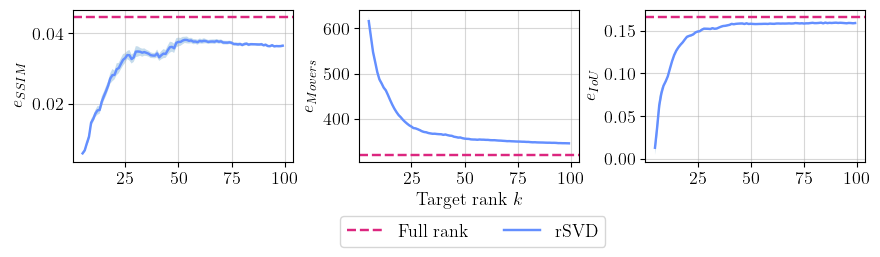

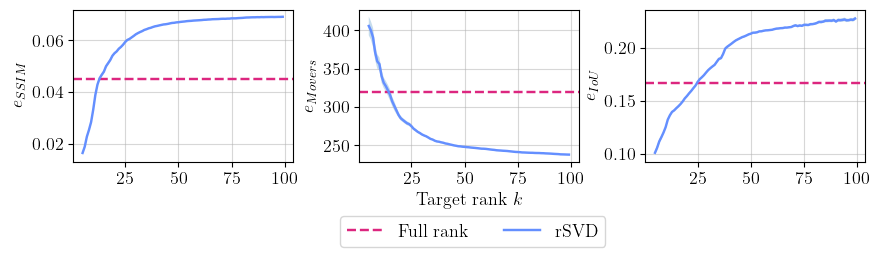

In [21]:
from utils.colors import C2

def plot_rsvd_over_k(df, df_exact, fig_name=None):
    stats = df.groupby("k").agg(["mean", "std", "count"])

    fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharex=True)
    axes = axes.flatten()

    dists = ['SSIM', 'Movers', 'IoU']

    for ax, dist in zip(axes, dists):
        key = dist.lower()

        mean = stats[(key, "mean")]
        std = stats[(key, "std")]
        n = stats[(key, "count")]

        ci95 = 1.96 * std / np.sqrt(n)
        k_vals = mean.index

        ax.axhline(df_exact[key][0], ls='--', c=C2[1], lw=1.75, label='Full rank')

        ax.plot(k_vals, mean, c=C2[0], lw=1.75, label='rSVD')
        ax.fill_between(k_vals, mean - ci95, mean + ci95, alpha=0.25)
        
        ax.xaxis.set_major_locator(MultipleLocator(25))
        ax.grid(alpha=.5)
        ax.set_ylabel(fr"$e_{{{dist}}}$")

    axes[1].set_xlabel("Target rank $k$")
    
    axes[1].legend(loc='upper right', ncols=2, bbox_to_anchor=(1.16, -0.3), fontsize=13)


    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)
    if fig_name is not None:
        plt.savefig(f'../figures/{fig_name}', dpi=300, bbox_inches='tight')
    plt.show()

plot_rsvd_over_k(df, df_exact, 'rsvd_over_k_I')
plot_rsvd_over_k(df_II, df_exact_II, 'rsvd_over_k_II')